# Лаб №2
## Графическое представление выборки



##  задание

Для непрерывной и дискретной выборок построить гистограмму, полигон частот и огиву, а также подсчитать абсолютные, относительные и накопленные частоты.

##  данные

Непрерывная выборка объёма `n = 26`:

```text
6.52, 9.27, 7.91, 5.77, 8.02, 3.07, 2.22, 5.76, 11.60, 6.62, 7.07, 12.50, 1.65, 10.50, 3.67, 7.62, 4.94, 5.39, 3.64, 4.62, 8.88, 6.75, 5.77, 6.38, 10.30, 5.74
```

Дискретная выборка объёма `n = 30`:

```text
4, 2, 1, 5, 1, 2, 4, 5, 3, 4, 4, 0, 1, 5, 1, 3, 3, 4, 0, 2, 3, 1, 3, 2, 1, 2, 4, 2, 0, 2
```


## 1. Теоретическая часть

Для визуального анализа выборки используют:

- **гистограмму** для оценки распределения частот по интервалам;
- **полигон частот** для соединения точек $(x_i, \omega_i)$;
- **огиву** для отображения накопленных относительных частот.

Для непрерывной выборки данные группируют по интервалам одинаковой длины $\Delta$.
Высота столбца гистограммы для i-го интервала определяется по формуле

$$
h_i = \frac{\omega_i}{\Delta_i} = \frac{n_i}{n\Delta_i},
$$

где $n_i$ - частота, $\omega_i$ - относительная частота, $n$ - объём выборки, $\Delta_i$ - ширина интервала.

Для дискретной выборки ширина интервала равна 1, поэтому высота столбца совпадает с относительной частотой.

Выборочная функция распределения строится по формуле

$$
F_n^*(x) = \sum_{j=1}^{i} \omega_j.
$$


In [46]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Исходные данные
continuous = [6.52, 9.27, 7.91, 5.77, 8.02, 3.07, 2.22, 5.76, 11.6, 6.62, 7.07, 12.5, 1.65, 10.5, 3.67, 7.62, 4.94, 5.39, 3.64, 4.62, 8.88, 6.75, 5.77, 6.38, 10.3, 5.74]
discrete = [4, 2, 1, 5, 1, 2, 4, 5, 3, 4, 4, 0, 1, 5, 1, 3, 3, 4, 0, 2, 3, 1, 3, 2, 1, 2, 4, 2, 0, 2]


#### 1. Интервальный вариационный ряд 

* **Границы интервалов:**
  Разбиение отрезка от $x_{min}$ до $x_{max}$ на $k$ равных интервалов с шагом $h$:
  $$h = \frac{x_{max} - x_{min}}{k}$$
  Границы определяются как:
  $$x_i = x_{min} + i \cdot h, \quad i = 0, 1, \dots, k$$

* **Относительные частоты:**
  Показывают долю элементов выборки, попавших в $i$-й интервал:
  $$p_i = \frac{n_i}{n}$$
  *Где $n_i$ — абсолютная частота интервала, а $n$ .*

* **Накопленные относительные частоты :**
  Сумма относительных частот всех интервалов от первого до текущего $m$-го:
  $$F_m = \sum_{i=1}^{m} p_i$$

* **Середины интервалов :**
  $$x_{mid, i} = \frac{x_i + x_{i+1}}{2}$$

* **Плотность частоты :**
  Отношение относительной частоты к ширине интервала (служит для построения гистограмм):
  $$f_i = \frac{p_i}{\Delta x_i} = \frac{p_i}{x_{i+1} - x_i}$$



In [47]:
def md_table(headers, rows):
    widths = [len(h) for h in headers]
    rows = [[str(cell) for cell in row] for row in rows]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(cell))
    def row_line(row):
        return "| " + " | ".join(row[i].ljust(widths[i]) for i in range(len(headers))) + " |"
    lines = [row_line(headers), "| " + " | ".join("-" * w for w in widths) + " |"]
    lines.extend(row_line(row) for row in rows)
    return "\n".join(lines)

def interval_series(sample, intervals=5):
    arr = np.asarray(sample, dtype=float)

    edges = np.linspace(arr.min(), arr.max(), intervals + 1)
    
    
    counts, _ = np.histogram(arr, bins=edges)
    ot_chastot = counts / arr.size

    nakop_chastoti = np.cumsum(ot_chastot)
    
    mids = (edges[:-1] + edges[1:]) / 2
    
    plotnost = ot_chastot / np.diff(edges)
    
    # Возвращаем все вычисленные параметры интервального ряда
    return edges, mids, counts, ot_chastot, nakop_chastoti, plotnost



#### 2. Дискретный вариационный ряд
* **Относительные частоты :**
  Доля конкретного уникального значения $x_i$ в выборке:
  $$p_i = \frac{n_i}{n}$$
  *Где $n_i$ — сколько раз встретилось значение $x_i$, а $n$ — объем выборки.*

* **Накопленные относительные частоты :**
  $$F_m = \sum_{i=1}^{m} p_i$$

* **Плотность (`plotnost`):**
  Для дискретного ряда шаг между соседними элементами условно принимается равным единице ($\Delta x = 1$), поэтому плотность совпадает с относительной частотой:
  $$f_i = p_i$$

In [48]:
def discrete_series(sample):

    arr = np.asarray(sample, dtype=int)
    # values   массив уникальных элементов, counts  массив их количеств.
    values, counts = np.unique(arr, return_counts=True)
    ot_chastot = counts / arr.size
    
    nakop_chastoti = np.cumsum(ot_chastot)
    
    plotnost = ot_chastot  
    
    # Возвращаем все рассчитанные массивы для дальнейшего построения графиков и таблиц
    return values, counts, ot_chastot, nakop_chastoti, plotnost

In [49]:
edges_c, mids_c, counts_c, ot_chastot_c, cum_c, density_c = interval_series(continuous, intervals=5)
values_d, counts_d, ot_chastot_d, cum_d, density_d = discrete_series(discrete)

print("Непрерывная выборка (Вариант 6):")
print(md_table(["Интервал", "Середина", "Частота", "Отн. частота", "Плотность отн. частоты", "Накопл. отн. частота"], [
    [f"[{edges_c[i]:.4f}; {edges_c[i+1]:.4f}]", f"{mids_c[i]:.4f}", str(int(counts_c[i])), f"{ot_chastot_c[i]:.4f}", f"{density_c[i]:.4f}", f"{cum_c[i]:.4f}" ] for i in range(len(counts_c))
]))

print("\n" + "="*80 + "\n")

print("Дискретная выборка (Вариант 6):")
print(md_table(["Варианта", "Частота", "Отн. частота", "Плотность отн. частоты", "Накопл. отн. частота"], [
    [str(int(v)), str(int(c)), f"{r:.4f}", f"{d:.4f}", f"{k:.4f}"] for v, c, r, d, k in zip(values_d, counts_d, ot_chastot_d, density_d, cum_d)
]))

print("\n" + "="*80 + "\n")



Непрерывная выборка (Вариант 6):
| Интервал           | Середина | Частота | Отн. частота | Плотность отн. частоты | Накопл. отн. частота |
| ------------------ | -------- | ------- | ------------ | ---------------------- | -------------------- |
| [1.6500; 3.8200]   | 2.7350   | 5       | 0.1923       | 0.0886                 | 0.1923               |
| [3.8200; 5.9900]   | 4.9050   | 7       | 0.2692       | 0.1241                 | 0.4615               |
| [5.9900; 8.1600]   | 7.0750   | 8       | 0.3077       | 0.1418                 | 0.7692               |
| [8.1600; 10.3300]  | 9.2450   | 3       | 0.1154       | 0.0532                 | 0.8846               |
| [10.3300; 12.5000] | 11.4150  | 3       | 0.1154       | 0.0532                 | 1.0000               |


Дискретная выборка (Вариант 6):
| Варианта | Частота | Отн. частота | Плотность отн. частоты | Накопл. отн. частота |
| -------- | ------- | ------------ | ---------------------- | -------------------- |
| 0        |

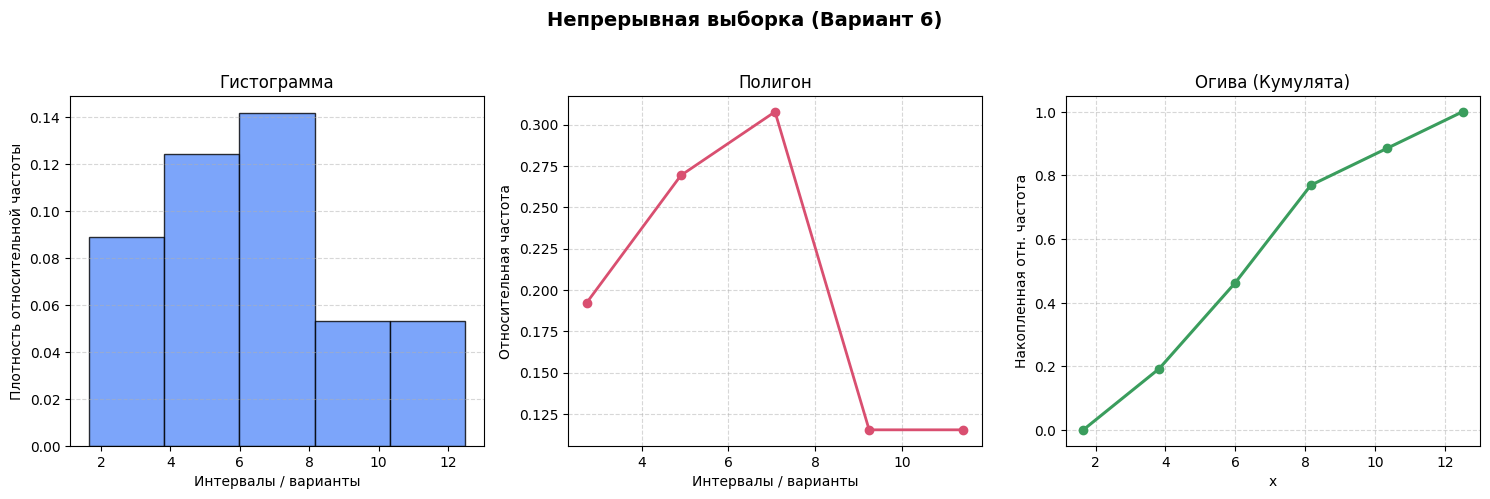

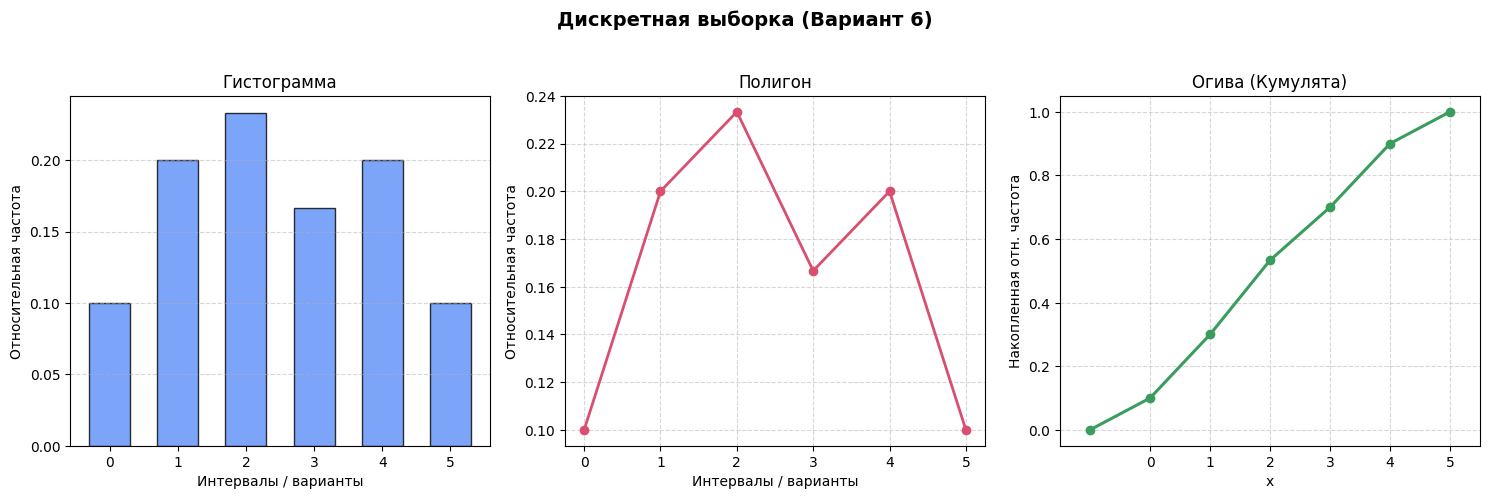

In [50]:
def plot_graphs(sample, title, discrete=False):
    """Отрисовка гистограммы, полигона и огивы для выборки."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    
    if discrete:
        values, counts, ot_chastot, nakop_chastoti, plotnost = discrete_series(sample)
        # 1. Гистограмма (для дискретного ряда строится по границам вокруг вариант)
        edges = np.arange(values.min() - 0.5, values.max() + 1.5, 1.0)
        width = np.diff(edges)
        axes[0].bar(values, ot_chastot, width=0.6, color="#5B8FF9", edgecolor="black", alpha=0.8)
        axes[0].set_ylabel("Относительная частота")
        axes[0].set_xticks(values)
        
        # 2. Полигон частот (соединяет точки самих вариант)
        axes[1].plot(values, ot_chastot, marker="o", color="#D94F70", linewidth=2.0)
        axes[1].set_ylabel("Относительная частота")
        axes[1].set_xticks(values)
        
        # 3. Огива дискретного ряда (ТЕПЕРЬ НЕСТУПЕНЧАТАЯ)
        # Добавляем фиктивную точку слева (значение_минимум - 1) с накопленной частотой 0
        x_disc = np.concatenate(([values[0] - 1], values))
        y_disc = np.concatenate(([0], nakop_chastoti))
        
        # Используем обычный plot вместо step для создания ломаной линии
        axes[2].plot(x_disc, y_disc, marker="o", color="#3A9D5D", linewidth=2.2)
        axes[2].set_xlim(x_disc[0] - 0.5, x_disc[-1] + 0.5)
        axes[2].set_xticks(values) # Отображаем на оси x только реальные варианты
        
    else:
        edges, mids, counts, ot_chastot, nakop_chastoti, plotnost = interval_series(sample, intervals=5)
        width = np.diff(edges)
        # 1. Гистограмма (высота столбцов — плотность относительной частоты)
        axes[0].bar(mids, plotnost, width=width, color="#5B8FF9", edgecolor="black", alpha=0.8)
        axes[0].set_ylabel("Плотность относительной частоты")
        
        # 2. Полигон (для интервального ряда традиционно соединяет середины интервалов)
        axes[1].plot(mids, ot_chastot, marker="o", color="#D94F70", linewidth=2.0)
        axes[1].set_ylabel("Относительная частота")
        
        # 3. Огива непрерывного ряда (кумулята — непрерывная ломаная линия от 0 до 1 по границам)
        x_cont = edges
        y_cont = np.concatenate(([0], nakop_chastoti))
        axes[2].plot(x_cont, y_cont, marker="o", color="#3A9D5D", linewidth=2.2)
        axes[2].set_xlim(edges[0] - 0.5, edges[-1] + 0.5)

    # Общие параметры для всех графиков
    axes[0].set_title("Гистограмма")
    axes[0].set_xlabel("Интервалы / варианты")
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    axes[1].set_title("Полигон")
    axes[1].set_xlabel("Интервалы / варианты")
    axes[1].grid(linestyle="--", alpha=0.5)

    axes[2].set_title("Огива (Кумулята)")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("Накопленная отн. частота")
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].grid(linestyle="--", alpha=0.5)

    fig.suptitle(title, y=1.03, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()
# --- Отрисовка графиков ---
plot_graphs(continuous, "Непрерывная выборка (Вариант 6)", discrete=False)
plot_graphs(discrete, "Дискретная выборка (Вариант 6)", discrete=True)